In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pypair.association import binary_binary
from pypair.util import corr
from scipy.stats import chi2_contingency
from itertools import combinations
import statsmodels.api as sm
import networkx as nx
from sklearn.metrics import pairwise_distances 

# DF1

In [2]:
#inputing collected data 
papers = [
    {
        "paper_id": "P1",
        "results_category": "both",
        "method": "quant",
        "sample_size": 201,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "primary_tags": [1, 2, 5],
        "secondary_tags": [4], 
        },
    {
        "paper_id": "P2",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4],
        "secondary_tags": [3, 6], 
        },
    {
        "paper_id": "P3",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 200,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [2, 3],
        "secondary_tags": [1, 4, 5, 6], 
        },
    {
        "paper_id": "P4",
        "results_category": "both",
        "method": "quant",
        "sample_size": 400,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [2, 4, 5],
        "secondary_tags": [1, 3], 
        },
    {
        "paper_id": "P5",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 11,
        "tool": ["gpt", "other"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [3, 6],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P6",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4, 5],
        "secondary_tags": [1, 3], 
        },
    {
        "paper_id": "P7",
        "results_category": "both",
        "method": "quant",
        "sample_size": 938,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "north_am",
        "primary_tags": [1, 7],
        "secondary_tags": [2, 3, 6], 
        },
    {
        "paper_id": "P8",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": np.nan,
        "primary_tags": [3, 4],
        "secondary_tags": [1, 5, 6], 
        },
    {
        "paper_id": "P9",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [2, 5, 7],
        "secondary_tags": [1, 3, 4], 
        },
    {
        "paper_id": "P10",
        "results_category": "challange",
        "method": "qual",
        "sample_size": 56,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": "interd",
        "region": "europe",
        "primary_tags": [5, 7],
        "secondary_tags": [0], 
        },
    {
        "paper_id": "P11",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 111,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [2, 5],
        "secondary_tags": [1, 3, 4], 
        },
    {
        "paper_id": "P12",
        "results_category": "both",
        "method": "qual",
        "sample_size": 300,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": "interd",
        "region": np.nan,
        "primary_tags": [4],
        "secondary_tags": [3, 5], 
        },
    {
        "paper_id": "P13",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 503,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "interd",
        "region": "europe",
        "primary_tags": [1, 4],
        "secondary_tags": [5], 
        },
    {
        "paper_id": "P14",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4],
        "secondary_tags": [3, 5, 7], 
        },
    {
        "paper_id": "P15",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 54,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "primary_tags": [1, 3],
        "secondary_tags": [2, 4, 6], 
        },
    {
        "paper_id": "P16",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 14878,
        "tool": "other",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [3, 4],
        "secondary_tags": [5, 6], 
        },
    {
        "paper_id": "P17",
        "results_category": "challange",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [4],
        "secondary_tags": [5], 
        },
    {
        "paper_id": "P18",
        "results_category": "both",
        "method": "qual",
        "sample_size": 36,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [4, 5],
        "secondary_tags": [1, 3, 7], 
        },
    {
        "paper_id": "P19",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 695,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [2, 5],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P20",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 40,
        "tool": "google",
        "focus_group": "student",
        "discipline": "stem",
        "region": "south_am",
        "primary_tags": [3],
        "secondary_tags": [1, 2, 6], 
        },
    {
        "paper_id": "P21",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "primary_tags": [5],
        "secondary_tags": [1, 4, 7], 
        },
    {
        "paper_id": "P22",
        "results_category": "both",
        "method": "qual",
        "sample_size": 30,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [5],
        "secondary_tags": [1, 4, 7], 
        },
    {
        "paper_id": "P23",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4],
        "secondary_tags": [1, 3, 5], 
        },
    {
        "paper_id": "P24",
        "results_category": "both",
        "method": "qual",
        "sample_size": 5,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [2, 4],
        "secondary_tags": [1, 5], 
        },
    {
        "paper_id": "P25",
        "results_category": "both",
        "method": "quant",
        "sample_size": 703,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "north_am",
        "primary_tags": [5],
        "secondary_tags": [1, 2, 4], 
        },
    {
        "paper_id": "P26",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [6, 7],
        "secondary_tags": [3, 5], 
        },
    {
        "paper_id": "P27",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 35,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [4],
        "secondary_tags": [1, 2, 3, 5], 
        },
    {
        "paper_id": "P28",
        "results_category": "both",
        "method": "quant",
        "sample_size": 223,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "internat",
        "primary_tags": [2, 3],
        "secondary_tags": [1, 4, 5], 
        },
    {
        "paper_id": "P29",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 336,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [1, 3, 5],
        "secondary_tags": [2], 
        },
    {
        "paper_id": "P30",
        "results_category": "both",
        "method": "qual",
        "sample_size": 75,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [2, 3, 5],
        "secondary_tags": [1, 4], 
        },
    {
        "paper_id": "P31",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 40,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "primary_tags": [1, 4, 5],
        "secondary_tags": [3, 7], 
        },
    {
        "paper_id": "P32",
        "results_category": "both",
        "method": "qual",
        "sample_size": 40,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [2, 4],
        "secondary_tags": [1, 5], 
        },
    {
        "paper_id": "P33",
        "results_category": "both",
        "method": "quant",
        "sample_size": 422,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [1, 2],
        "secondary_tags": [6], 
        },
    {
        "paper_id": "P34",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4, 5],
        "secondary_tags": [3], 
        },
    {
        "paper_id": "P35",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "primary_tags": [3, 6],
        "secondary_tags": [7], 
        },
    {
        "paper_id": "P36",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "primary_tags": [4, 5],
        "secondary_tags": [3, 7], 
        },
    {
        "paper_id": "P37",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [5, 7],
        "secondary_tags": [3], 
        },
    {
        "paper_id": "P38",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 5],
        "secondary_tags": [3, 7], 
        },
    {
        "paper_id": "P39",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 115,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [1, 3],
        "secondary_tags": [2, 6], 
        },
    {
        "paper_id": "P40",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 42,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [2, 3],
        "secondary_tags": [1, 6], 
        },
    {
        "paper_id": "P41",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 5],
        "secondary_tags": [3, 4], 
        },
    {
        "paper_id": "P42",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4, 5, 7],
        "secondary_tags": [1, 3, 6], 
        },
    {
        "paper_id": "P43",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [3, 4],
        "secondary_tags": [1, 2, 5, 7], 
        },
    {
        "paper_id": "P44",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 60,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "primary_tags": [3, 4],
        "secondary_tags": [1, 5], 
        },
    {
        "paper_id": "P45",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 1484,
        "tool": ["gpt", "google", "microsoft", "claude"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [1, 4, 5],
        "secondary_tags": [2, 3], 
        },
    {
        "paper_id": "P46",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 10,
        "tool": ["gpt", "google", "microsoft", "other"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "oceania",
        "primary_tags": [3, 4, 5],
        "secondary_tags": [1, 2], 
        },
    {
        "paper_id": "P47",
        "results_category": "both",
        "method": "qual",
        "sample_size": 355,
        "tool": ["gpt", "google", "other"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 3],
        "secondary_tags": [4, 5, 6, 7], 
        },
    {
        "paper_id": "P48",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 20,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [1, 3],
        "secondary_tags": [2, 5, 6], 
        },
    {
        "paper_id": "P49",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [3, 4, 5],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P50",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 355,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [1, 2],
        "secondary_tags": [4, 5], 
        },
    {
        "paper_id": "P51",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": np.nan,
        "primary_tags": [3, 5],
        "secondary_tags": [1, 4], 
        },
    {
        "paper_id": "P52",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 80,
        "tool": ["gpt", "microsoft"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [3, 5],
        "secondary_tags": [6], 
        },
    {
        "paper_id": "P53",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 193,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "interd",
        "region": "asia",
        "primary_tags": [1, 2],
        "secondary_tags": [3], 
        },
    {
        "paper_id": "P54",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 385,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "primary_tags": [2, 5],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P55",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "other",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [6],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P56",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4, 5],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P57",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": "other",
        "focus_group": "student",
        "discipline": "hum",
        "region": "south_am",
        "primary_tags": [5, 6],
        "secondary_tags": [3], 
        },
    {
        "paper_id": "P58",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 22,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [3, 6],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P59",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 362,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [2, 3, 5],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P60",
        "results_category": "both",
        "method": "quant",
        "sample_size": 1195,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [1, 2],
        "secondary_tags": [7], 
        },
    {
        "paper_id": "P61",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": ["gpt", "google"],
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "north_am",
        "primary_tags": [5],
        "secondary_tags": [4], 
        },
    {
        "paper_id": "P62",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 600,
        "tool": "other",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [3, 4],
        "secondary_tags": [5], 
        },
    {
        "paper_id": "P63",
        "results_category": "both",
        "method": "quant",
        "sample_size": 361,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [1, 2],
        "secondary_tags": [3, 5], 
        },
    {
        "paper_id": "P64",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 1189,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [3, 6],
        "secondary_tags": [1, 7], 
        },
    {
        "paper_id": "P65",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 25,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [1, 3, 6],
        "secondary_tags": [2, 5], 
        },
    {
        "paper_id": "P66",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 24,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "primary_tags": [2, 3, 4],
        "secondary_tags": [1, 5], 
        },
    {
        "paper_id": "P67",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 918,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "hum",
        "region": "asia",
        "primary_tags": [3, 6],
        "secondary_tags": [1, 2, 4], 
        },
    {
        "paper_id": "P68",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 14,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [2, 6, 7],
        "secondary_tags": [1, 3, 5], 
        },
    {
        "paper_id": "P69",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 76,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [3, 4],
        "secondary_tags": [2, 5, 6], 
        },
    {
        "paper_id": "P70",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 365,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "primary_tags": [1, 5, 7],
        "secondary_tags": [2, 3, 6], 
        },
    {
        "paper_id": "P71",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": ["europe", "south_am"],
        "primary_tags": [3, 4, 6],
        "secondary_tags": [2, 5], 
        },
    {
        "paper_id": "P72",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 45,
        "tool": "other",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "primary_tags": [3, 6],
        "secondary_tags": [1, 2], 
        },
    {
        "paper_id": "P73",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 12,
        "tool": ["gpt", "google", "microsoft"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [4],
        "secondary_tags": [3, 5], 
        },
    {
        "paper_id": "P74",
        "results_category": "both",
        "method": "qual",
        "sample_size": 48,
        "tool": ["gpt", "google", "microsoft",  "claude"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [1, 4, 5],
        "secondary_tags": [2, 3, 7], 
        },
    {
        "paper_id": "P75",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 90,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [4, 5],
        "secondary_tags": [2, 3], 
        },
    {
        "paper_id": "P76",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 61,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "primary_tags": [1, 3, 4],
        "secondary_tags": [2, 6], 
        },
    {
        "paper_id": "P77",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 6],
        "secondary_tags": [3, 5], 
        },
    {
        "paper_id": "P78",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [1, 3, 5],
        "secondary_tags": [2, 6], 
        },
    {
        "paper_id": "P79",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 4,
        "tool": "other",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "primary_tags": [2, 3, 6],
        "secondary_tags": [1, 4, 5], 
        },
    {
        "paper_id": "P80",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 1217,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": "interd",
        "region": "internat",
        "primary_tags": [1, 2, 5],
        "secondary_tags": [3, 4, 7], 
        },
    {
        "paper_id": "P81",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 4, 5],
        "secondary_tags": [2, 3, 6], 
        },
    {
        "paper_id": "P82",
        "results_category": "both",
        "method": "qual",
        "sample_size": 20,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 3],
        "secondary_tags": [2, 5, 7], 
        },
    {
        "paper_id": "P83",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [5],
        "secondary_tags": [1], 
        },
    {
        "paper_id": "P84",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "primary_tags": [3, 6],
        "secondary_tags": [1, 5], 
        },
    {
        "paper_id": "P85",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "africa",
        "primary_tags": [1, 5, 7],
        "secondary_tags": [3, 4, 6], 
        },
    {
        "paper_id": "P86",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 85,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [1, 2, 3, 5],
        "secondary_tags": [4, 7], 
        },
    {
        "paper_id": "P87",
        "results_category": "challange",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [4, 5],
        "secondary_tags": [2, 7], 
        },
    {
        "paper_id": "P88",
        "results_category": "both",
        "method": "quant",
        "sample_size": 393,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [3, 5],
        "secondary_tags": [1, 4], 
        },
    {
        "paper_id": "P89",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [3, 5],
        "secondary_tags": [2, 4, 7], 
        },
    {
        "paper_id": "P90",
        "results_category": "both",
        "method": "qual",
        "sample_size": 38,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [2, 3, 5],
        "secondary_tags": [1, 4], 
        },
    {
        "paper_id": "P91",
        "results_category": "both",
        "method": "qual",
        "sample_size": 23,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "africa",
        "primary_tags": [2, 5],
        "secondary_tags": [1, 3, 4], 
        },
    {
        "paper_id": "P92",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 234,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": ["europe", "south_am"],
        "primary_tags": [1, 3],
        "secondary_tags": [2, 5, 6], 
        },
    {
        "paper_id": "P93",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 122,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [1, 3],
        "secondary_tags": [2, 5], 
        },
    {
        "paper_id": "P94",
        "results_category": "both",
        "method": "quant",
        "sample_size": 82,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "primary_tags": [1, 3],
        "secondary_tags": [2, 5], 
        },
    {
        "paper_id": "P95",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 140,
        "tool": ["gpt", "google", "claude"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "africa",
        "primary_tags": [1, 3],
        "secondary_tags": [2, 4, 5], 
        },
    {
        "paper_id": "P96",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 501,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "primary_tags": [1, 2, 3],
        "secondary_tags": [5, 6], 
        },
    {
        "paper_id": "P97",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [3, 6],
        "secondary_tags": [1, 2, 5, 7], 
        },
    {
        "paper_id": "P98",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 1054,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "primary_tags": [1, 2, 3, 4],
        "secondary_tags": [5, 6, 7], 
        },
    {
        "paper_id": "P99",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 85,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "primary_tags": [1, 2, 3, 5],
        "secondary_tags": [4, 7], 
        },
    {
        "paper_id": "P100",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 3, 5],
        "secondary_tags": [2, 4, 7], 
        },
    {
        "paper_id": "P101",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 3],
        "secondary_tags": [4, 5, 6, 7], 
        },
    {
        "paper_id": "P102",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 3, 5],
        "secondary_tags": [2, 4, 6, 7], 
        },
    {
        "paper_id": "P103",
        "results_category": "both",
        "method": "qual",
        "sample_size": 138,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 3],
        "secondary_tags": [2, 4, 5, 6, 7], 
        },
    {
        "paper_id": "P104",
        "results_category": "both",
        "method": "qual",
        "sample_size": 116,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 4, 5],
        "secondary_tags": [2, 3, 7], 
        },
    {
        "paper_id": "P105",
        "results_category": "both",
        "method": "qual",
        "sample_size": 37,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "primary_tags": [1, 3, 5],
        "secondary_tags": [2, 4, 6, 7], 
        }
]

# DF1 analysis

In [3]:
#turning the papers dictionary into a dataframe
df1 = pd.DataFrame(papers).set_index("paper_id") #setting paper_id as index
df1

,results_category,method,sample_size,tool,focus_group,discipline,region,primary_tags,secondary_tags
paper_id,,,,,,,,,
P1,both,quant,201.0,gpt,student,NaN,south_am,"[1, 2, 5]",[4]
P2,opportunity,qual,NaN,NaN,mixed,NaN,NaN,[4],"[3, 6]"
P3,both,mixed,200.0,NaN,mixed,NaN,asia,"[2, 3]","[1, 4, 5, 6]"
P4,both,quant,400.0,gpt,student,NaN,asia,"[2, 4, 5]","[1, 3]"
P5,opportunity,mixed,11.0,"[gpt, other]",mixed,NaN,europe,"[3, 6]",[1]
...,...,...,...,...,...,...,...,...,...
P101,both,qual,NaN,NaN,mixed,NaN,NaN,"[1, 3]","[4, 5, 6, 7]"
P102,both,qual,NaN,gpt,mixed,NaN,NaN,"[1, 3, 5]","[2, 4, 6, 7]"
P103,both,qual,138.0,NaN,mixed,NaN,NaN,"[1, 3]","[2, 4, 5, 6, 7]"


### General descriptive stats

Results category: 
 count      105
unique       3
top       both
freq        52
Name: results_category, dtype: object
Proportions of values: 
 results_category
both           0.495238
opportunity    0.304762
challange      0.200000
Name: proportion, dtype: float64


<Axes: xlabel='results_category'>

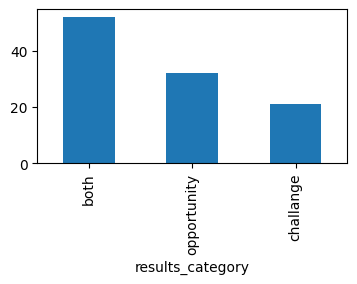

In [4]:
#visualising the frequency of results variables
print("Results category: \n", df1["results_category"].describe())
print("Proportions of values: \n", df1["results_category"].value_counts(normalize = True))
df1["results_category"].value_counts().plot(kind = "bar", figsize = (4, 2))

Method used: 
 count      105
unique       3
top       qual
freq        44
Name: method, dtype: object
Proportions of values: 
 method
qual     0.419048
quant    0.333333
mixed    0.247619
Name: proportion, dtype: float64


<Axes: xlabel='method'>

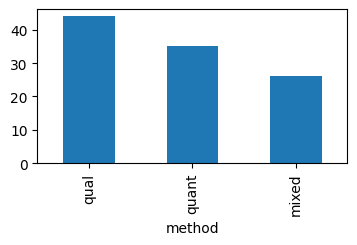

In [5]:
#visualising the frequency of method variable
print("Method used: \n", df1["method"].describe())
print("Proportions of values: \n", df1["method"].value_counts(normalize = True))
df1["method"].value_counts().plot(kind = "bar", figsize = (4, 2))

In [6]:
#using a descriptive statistic on sample size column with excluded P16 outlier (14,878)
df1.loc[df1.index != "P16", "sample_size"].describe()

count      68.000000
mean      268.367647
std       349.595242
min         4.000000
25%        39.500000
50%       100.500000
75%       362.750000
max      1484.000000
Name: sample_size, dtype: float64

In [7]:
#using descriptive statistics for sample size for each specific method
print("Sample size for qual method: \n", df1.loc[df1["method"] == "qual", "sample_size"].describe())
print("Sample size for quant method: \n", df1.loc[(df1.index != "P16") & (df1["method"] == "quant"), "sample_size"].describe())
print("Sample size for mixed method: \n", df1.loc[df1["method"] == "mixed", "sample_size"].describe())

Sample size for qual method: 
 count     18.000000
mean      76.388889
std       98.198562
min        4.000000
25%       24.750000
50%       39.000000
75%       70.250000
max      355.000000
Name: sample_size, dtype: float64
Sample size for quant method: 
 count      28.000000
mean      408.321429
std       392.756739
min        10.000000
25%        76.750000
50%       358.000000
75%       527.250000
max      1484.000000
Name: sample_size, dtype: float64
Sample size for mixed method: 
 count      22.000000
mean      247.318182
std       354.430783
min        11.000000
25%        45.000000
50%        87.500000
75%       198.250000
max      1217.000000
Name: sample_size, dtype: float64


In [8]:
#calculating total sample size for each specific method
print("Total sample size for qual method: \n", df1.loc[df1["method"] == "qual", "sample_size"].sum())
print("Total sample size for quant method: \n", df1.loc[(df1.index != "P16") & (df1["method"] == "quant"), "sample_size"].sum())
print("Total sample size for mixed method: \n", df1.loc[df1["method"] == "mixed", "sample_size"].sum())

Total sample size for qual method: 
 1375.0
Total sample size for quant method: 
 11433.0
Total sample size for mixed method: 
 5441.0


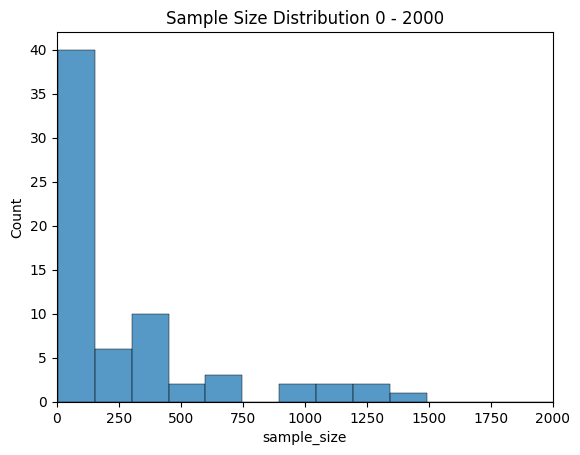

In [9]:
#visualising the distribution of sample sizes
sns.histplot(df1["sample_size"], bins = 100)
plt.title("Sample Size Distribution 0 - 2000")
plt.xlim(0, 2000) #hide the outlier above 2000
plt.show()

Tool examined: 
 count      66
unique     11
top       gpt
freq       46
Name: tool, dtype: object
Proportions of values: 
 tool
gpt                                 0.696970
other                               0.090909
[gpt, other]                        0.075758
[gpt, google, microsoft, claude]    0.030303
google                              0.015152
[gpt, google, microsoft, other]     0.015152
[gpt, google, other]                0.015152
[gpt, microsoft]                    0.015152
[gpt, google]                       0.015152
[gpt, google, microsoft]            0.015152
[gpt, google, claude]               0.015152
Name: proportion, dtype: float64


<Axes: xlabel='tool'>

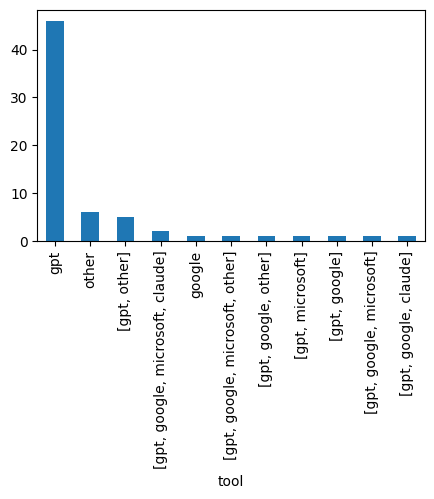

In [10]:
#visualising the frequencies of tool variables
print("Tool examined: \n", df1["tool"].describe())
print("Proportions of values: \n", df1["tool"].value_counts(normalize = True))
df1["tool"].value_counts().plot(kind = "bar", figsize = (5, 3))

Focus group: 
 count          96
unique          3
top       student
freq           59
Name: focus_group, dtype: object
Proportions of values: 
 focus_group
student    0.614583
mixed      0.333333
staff      0.052083
Name: proportion, dtype: float64


<Axes: xlabel='focus_group'>

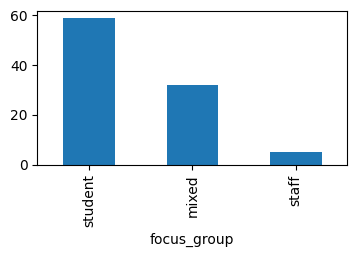

In [11]:
#visualising the frequency of focus group variables
print("Focus group: \n", df1["focus_group"].describe())
print("Proportions of values: \n", df1["focus_group"].value_counts(normalize = True))
df1["focus_group"].value_counts().plot(kind = "bar", figsize = (4, 2))

Discipline: 
 count       31
unique       3
top       stem
freq        24
Name: discipline, dtype: object
Proportions of values: 
 discipline
stem      0.774194
interd    0.161290
hum       0.064516
Name: proportion, dtype: float64


<Axes: xlabel='discipline'>

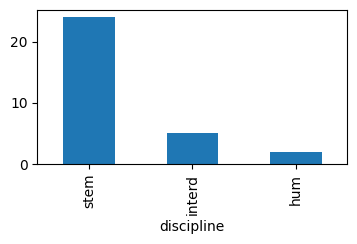

In [12]:
#visualising the frequency of discipline variables
print("Discipline: \n", df1["discipline"].describe())
print("Proportions of values: \n", df1["discipline"].value_counts(normalize = True))
df1["discipline"].value_counts().plot(kind = "bar", figsize = (4, 2))

Region: 
 count       72
unique       8
top       asia
freq        25
Name: region, dtype: object
Proportions of values: 
 region
asia                  0.347222
europe                0.333333
north_am              0.097222
south_am              0.069444
internat              0.069444
africa                0.041667
[europe, south_am]    0.027778
oceania               0.013889
Name: proportion, dtype: float64


<Axes: xlabel='region'>

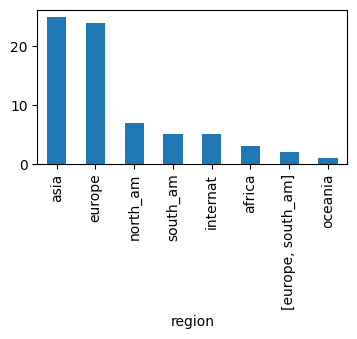

In [13]:
#visualising the frequency of region variables
print("Region: \n", df1["region"].describe())
print("Proportions of values: \n", df1["region"].value_counts(normalize = True))
df1["region"].value_counts().plot(kind = "bar", figsize = (4, 2))

In [14]:
pt = df1.explode("primary_tags")
print("Overall number of primary tags: \n", pt["primary_tags"].count())

Overall number of primary tags: 
 231


In [15]:
print("Primary tags: \n", df1["primary_tags"].describe())
print("Individual primary tag counts: \n", df1["primary_tags"].explode().value_counts())

Primary tags: 
 count        105
unique        38
top       [1, 3]
freq          11
Name: primary_tags, dtype: object
Individual primary tag counts: 
 primary_tags
3    52
5    49
1    41
4    36
2    28
6    16
7     9
Name: count, dtype: int64


In [16]:
st = df1.explode("secondary_tags")
print("Overall number of secondary tags: \n", st["secondary_tags"].count())

Overall number of secondary tags: 
 237


In [17]:
print("Secondary tags: \n", df1["secondary_tags"].describe())
print("Individual secondary tag counts: \n", df1["secondary_tags"].explode().value_counts())

Secondary tags: 
 count     105
unique     51
top       [1]
freq        9
Name: secondary_tags, dtype: object
Individual secondary tag counts: 
 secondary_tags
1    43
5    39
2    35
3    34
4    31
6    27
7    27
0     1
Name: count, dtype: int64


### Trends & cross category comparisons

Geographic results trends

In [18]:
#exploding lists for crosstabulation
reg = df1.explode("region").reset_index(drop = True)

#creating a contingency table showing count of each outcome within each region
pd.crosstab(
    reg["region"],
    reg["results_category"],
    margins = True #adding a sum row and column
)

results_category,both,challange,opportunity,All
region,,,,
africa,3,0,0,3
asia,10,2,13,25
europe,10,8,8,26
internat,2,2,1,5
north_am,3,0,4,7
oceania,0,1,0,1
south_am,1,2,4,7
All,29,15,30,74


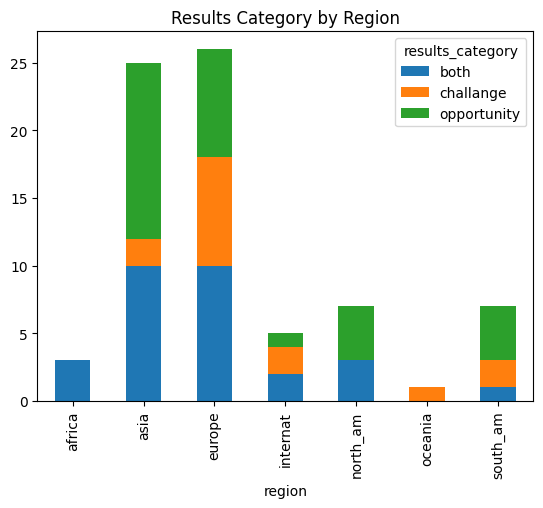

In [19]:
#exploding lists for crosstabulation
reg = df1.explode("region").reset_index(drop = True)

#creating a bar charg of results frequency by region
pd.crosstab(reg["region"], reg["results_category"]).plot(kind = "bar", stacked = True)
plt.title("Results Category by Region")
plt.show()

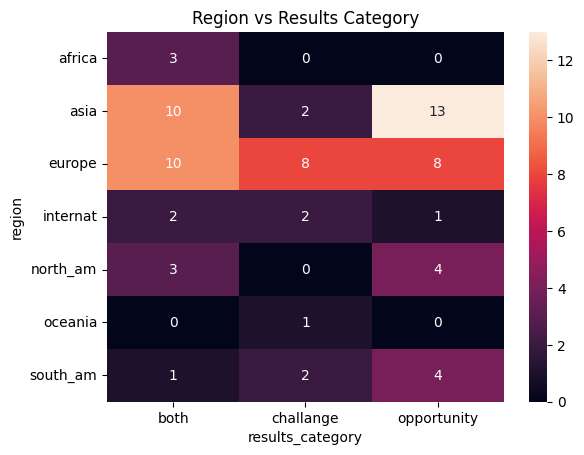

In [20]:
#exploding lists for crosstabulation
region_ex = df1.explode("region").reset_index(drop = True)

#creating a contingency table showing count of each outcome within each region
ct1 = pd.crosstab(region_ex["region"], region_ex["results_category"])

#visualising the table as a heatmap
sns.heatmap(ct1, annot = True)
plt.title("Region vs Results Category")
plt.show()

Method trends

In [21]:
#creating a contingency table showing count of each outcome by method
pd.crosstab(
    df1["method"],
    df1["results_category"],
    margins = True #adding a sum row and column
)

results_category,both,challange,opportunity,All
method,,,,
mixed,12,4,10,26
qual,30,8,6,44
quant,10,9,16,35
All,52,21,32,105


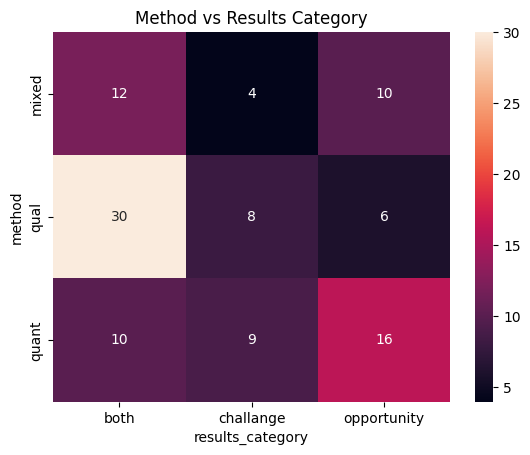

In [22]:
#creating a contingency table showing count of each outcome by method
ct2 = pd.crosstab(df1["method"], df1["results_category"])

#visualising the table as a heatmaps
sns.heatmap(ct2, annot = True)
plt.title("Method vs Results Category")
plt.show()

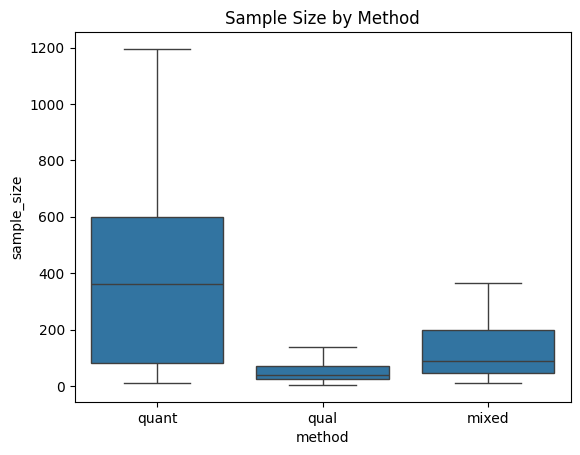

In [23]:
#creating a boxplot to visualise sample size by method
sns.boxplot(x = "method", y = "sample_size", data = df1, showfliers = False) #removing the outlier from P16
plt.title("Sample Size by Method")
plt.show()

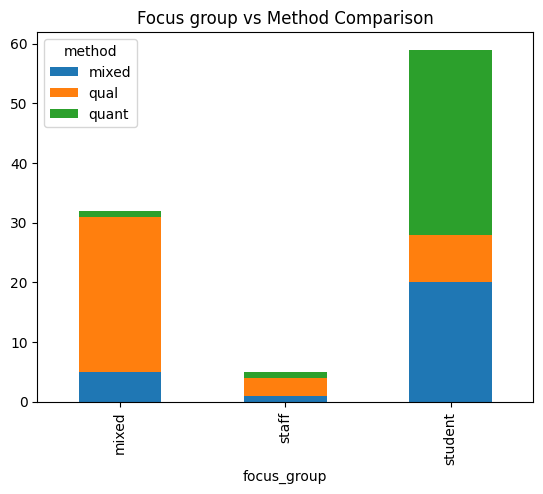

In [24]:
#creating a bar graph to visualise focus group vs method frequencies
pd.crosstab(df1["focus_group"], df1["method"]).plot(kind = "bar", stacked = True)
plt.title("Focus group vs Method Comparison")
plt.show()

Missing Values Heatmap

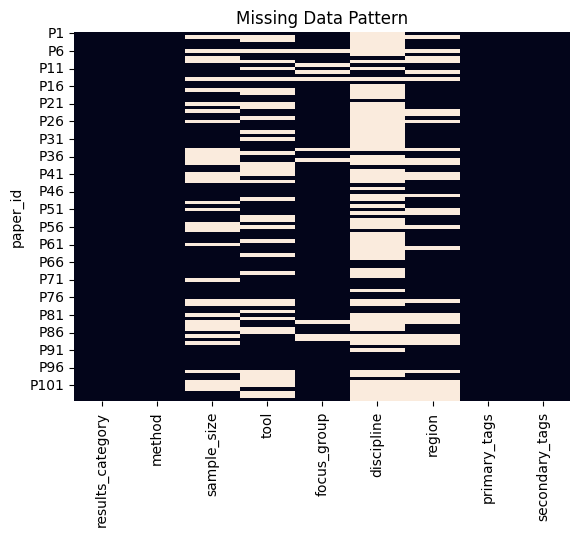

In [25]:
#visualising the pattern of NaN values using heatmap
sns.heatmap(df1.isna(), cbar = False)
plt.title("Missing Data Pattern")
plt.show()

### Tags trends

In [26]:
#exploding lists for crosstabulation
tag1 = df1.explode("primary_tags").reset_index(drop = True)

#creating a contingency table showing a count of primary tags for each outcome category
pd.crosstab(
    tag1["primary_tags"],
    tag1["results_category"],
    margins = True #adding a sum row and column
)

results_category,both,challange,opportunity,All
primary_tags,,,,
1,26,4,11,41
2,21,2,5,28
3,24,5,23,52
4,16,11,9,36
5,27,16,6,49
6,2,0,14,16
7,5,3,1,9
All,121,41,69,231


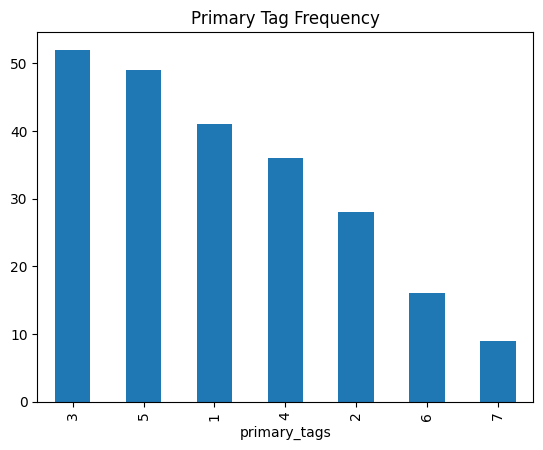

In [27]:
#visualising most common tags
df1.explode("primary_tags")["primary_tags"].value_counts().plot(kind = "bar")
plt.title("Primary Tag Frequency")
plt.show()

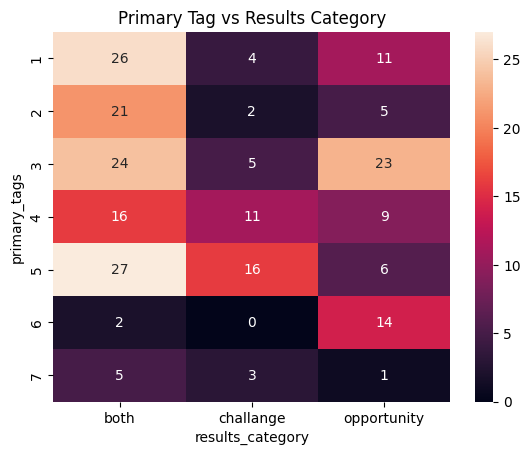

In [28]:
#exploding lists for crosstabulation
t1_ex = df1.explode("primary_tags").reset_index(drop = True)

#creating a contingency table showing a count of primary tags for each outcome category
ct3 = pd.crosstab(t1_ex["primary_tags"], t1_ex["results_category"])

sns.heatmap(ct3, annot = True)
plt.title("Primary Tag vs Results Category")
plt.show()

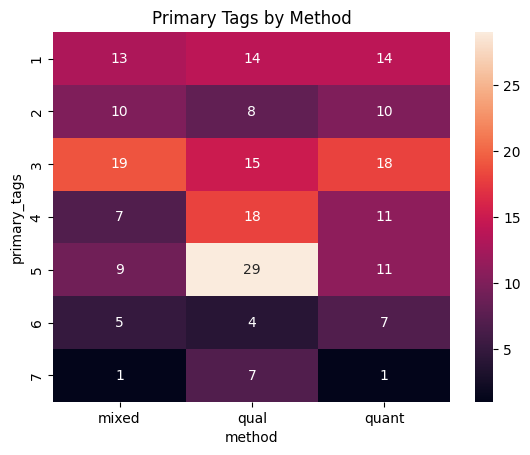

In [29]:
#exploding lists for crosstabulation
t1 = df1.explode("primary_tags").reset_index(drop = True)

#creating a contingency table showing a count of primary tags for each method variable
ct4 = pd.crosstab(t1["primary_tags"], t1["method"])
sns.heatmap(ct4, annot = True)
plt.title("Primary Tags by Method")
plt.show()

In [30]:
#exploding lists for crosstabulation
tag2 = df1.explode("secondary_tags").reset_index(drop = True)

#creating a contingency table showing a count of secondary tags for each outcome category
pd.crosstab(
    tag2["secondary_tags"],
    tag2["results_category"],
    margins = True #adding a sum row and column
)

results_category,both,challange,opportunity,All
secondary_tags,,,,
0,0,1,0,1
1,23,7,13,43
2,15,8,12,35
3,20,8,6,34
4,25,2,4,31
5,19,5,15,39
6,16,2,9,27
7,18,4,5,27
All,136,37,64,237


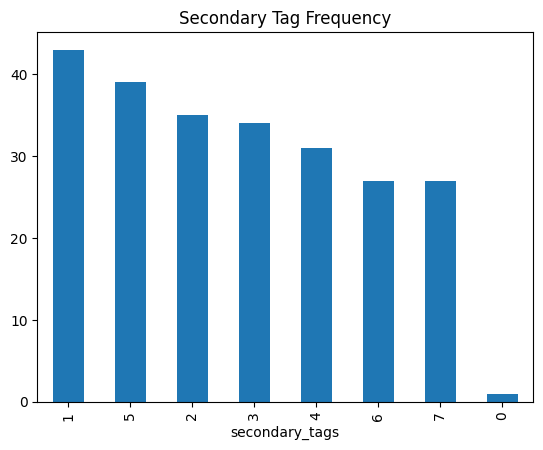

In [31]:
#visualising most common tags
df1.explode("secondary_tags")["secondary_tags"].value_counts().plot(kind = "bar")
plt.title("Secondary Tag Frequency")
plt.show()

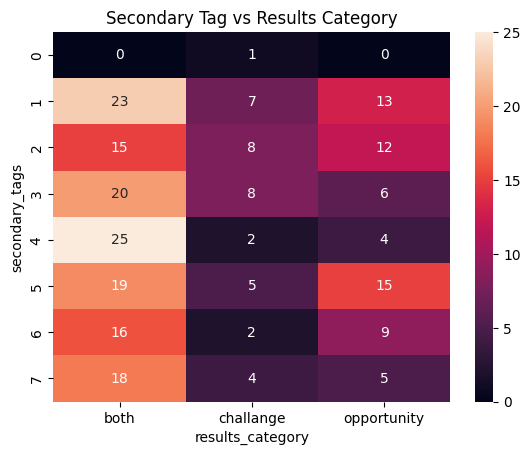

In [32]:
#exploding listst for crosstabulation
t2_ex = df1.explode("secondary_tags").reset_index(drop = True)

#creating a contingency table showing a count of secondary tags for each outcome category
ct5 = pd.crosstab(t2_ex["secondary_tags"], t2_ex["results_category"])

sns.heatmap(ct5, annot = True)
plt.title("Secondary Tag vs Results Category")
plt.show()

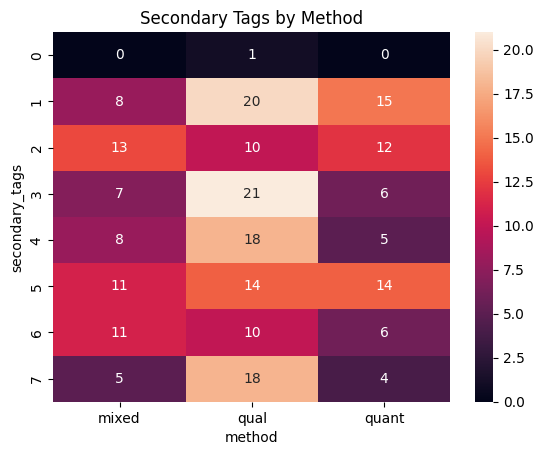

In [33]:
#exploding lists for crosstabulation
t2 = df1.explode("secondary_tags").reset_index(drop = True)

#creating a contingency table showing a count of secondary tags for each method variable
ct6 = pd.crosstab(t2["secondary_tags"], t2["method"])
sns.heatmap(ct6, annot = True)
plt.title("Secondary Tags by Method")
plt.show()

# DF2

In [34]:
#transforming the data to include a separate columns for each tag (accounting only for primary tags)
tags_1 = [
    {
        "paper_id": "P1",
        "results_category": "both",
        "method": "quant",
        "sample_size": 201,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P2",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P3",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 200,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P4",
        "results_category": "both",
        "method": "quant",
        "sample_size": 400,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P5",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 11,
        "tool": ["gpt", "other"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0, 
        },
    {
        "paper_id": "P6",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P7",
        "results_category": "both",
        "method": "quant",
        "sample_size": 938,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "north_am",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P8",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P9",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P10",
        "results_category": "challange",
        "method": "qual",
        "sample_size": 56,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": "interd",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P11",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 111,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P12",
        "results_category": "both",
        "method": "qual",
        "sample_size": 300,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": "interd",
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P13",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 503,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "interd",
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P14",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P15",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 54,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P16",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 14878,
        "tool": "other",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P17",
        "results_category": "challange",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P18",
        "results_category": "both",
        "method": "qual",
        "sample_size": 36,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P19",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 695,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P20",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 40,
        "tool": "google",
        "focus_group": "student",
        "discipline": "stem",
        "region": "south_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P21",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P22",
        "results_category": "both",
        "method": "qual",
        "sample_size": 30,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P23",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P24",
        "results_category": "both",
        "method": "qual",
        "sample_size": 5,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P25",
        "results_category": "both",
        "method": "quant",
        "sample_size": 703,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "north_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P26",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 1,
        },
    {
        "paper_id": "P27",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 35,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P28",
        "results_category": "both",
        "method": "quant",
        "sample_size": 223,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P29",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 336,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P30",
        "results_category": "both",
        "method": "qual",
        "sample_size": 75,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P31",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 40,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P32",
        "results_category": "both",
        "method": "qual",
        "sample_size": 40,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P33",
        "results_category": "both",
        "method": "quant",
        "sample_size": 422,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P34",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P35",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P36",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P37",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P38",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P39",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 115,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P40",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 42,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P41",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P42",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P43",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P44",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 60,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P45",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 1484,
        "tool": ["gpt", "google", "microsoft", "claude"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P46",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 10,
        "tool": ["gpt", "google", "microsoft", "other"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "oceania",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P47",
        "results_category": "both",
        "method": "qual",
        "sample_size": 355,
        "tool": ["gpt", "google", "other"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P48",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 20,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P49",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P50",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 355,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P51",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P52",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 80,
        "tool": ["gpt", "microsoft"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P53",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 193,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "interd",
        "region": "asia",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P54",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 385,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P55",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "other",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P56",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P57",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": "other",
        "focus_group": "student",
        "discipline": "hum",
        "region": "south_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P58",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 22,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0, 
        },
    {
        "paper_id": "P59",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 362,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P60",
        "results_category": "both",
        "method": "quant",
        "sample_size": 1195,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P61",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": ["gpt", "google"],
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "north_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P62",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 600,
        "tool": "other",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P63",
        "results_category": "both",
        "method": "quant",
        "sample_size": 361,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P64",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 1189,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P65",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 25,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P66",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 24,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P67",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 918,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "hum",
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P68",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 14,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 1,
        },
    {
        "paper_id": "P69",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 76,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P70",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 365,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P71",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": ["europe", "south_am"],
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P72",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 45,
        "tool": "other",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P73",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 12,
        "tool": ["gpt", "google", "microsoft"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P74",
        "results_category": "both",
        "method": "qual",
        "sample_size": 48,
        "tool": ["gpt", "google", "microsoft",  "claude"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P75",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 90,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P76",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 61,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P77",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P78",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P79",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 4,
        "tool": "other",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0, 
        },
    {
        "paper_id": "P80",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 1217,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": "interd",
        "region": "internat",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P81",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P82",
        "results_category": "both",
        "method": "qual",
        "sample_size": 20,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P83",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P84",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P85",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "africa",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P86",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 85,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P87",
        "results_category": "challange",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P88",
        "results_category": "both",
        "method": "quant",
        "sample_size": 393,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P89",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P90",
        "results_category": "both",
        "method": "qual",
        "sample_size": 38,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P91",
        "results_category": "both",
        "method": "qual",
        "sample_size": 23,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "africa",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P92",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 234,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": ["europe", "south_am"],
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P93",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 122,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P94",
        "results_category": "both",
        "method": "quant",
        "sample_size": 82,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P95",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 140,
        "tool": ["gpt", "google", "claude"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "africa",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P96",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 501,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P97",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P98",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 1054,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P99",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 85,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P100",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P101",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P102",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P103",
        "results_category": "both",
        "method": "qual",
        "sample_size": 138,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P104",
        "results_category": "both",
        "method": "qual",
        "sample_size": 116,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P105",
        "results_category": "both",
        "method": "qual",
        "sample_size": "37",
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        }
]

# DF2 analysis

In [35]:
#turning the tags_1 dictionary into a dataframe
df2 = pd.DataFrame(tags_1).set_index("paper_id")
df2

,results_category,method,sample_size,tool,focus_group,discipline,region,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
paper_id,,,,,,,,,,,,,,
P1,both,quant,201,gpt,student,NaN,south_am,1,1,0,0,1,0,0
P2,opportunity,qual,NaN,NaN,mixed,NaN,NaN,0,0,0,1,0,0,0
P3,both,mixed,200,NaN,mixed,NaN,asia,0,1,1,0,0,0,0
P4,both,quant,400,gpt,student,NaN,asia,0,1,0,1,1,0,0
P5,opportunity,mixed,11,"[gpt, other]",mixed,NaN,europe,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P101,both,qual,NaN,NaN,mixed,NaN,NaN,1,0,1,0,0,0,0
P102,both,qual,NaN,gpt,mixed,NaN,NaN,1,0,1,0,1,0,0
P103,both,qual,138,NaN,mixed,NaN,NaN,1,0,1,0,0,0,0


In [36]:
df2.describe()

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,0.390476,0.266667,0.495238,0.342857,0.466667,0.152381,0.085714
std,0.490197,0.444338,0.502375,0.476941,0.501280,0.361113,0.281284
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
#isolating themes columns into a separate daframe
themes = df2[["tag_1", "tag_2", "tag_3", "tag_4", "tag_5", "tag_6", "tag_7"]]
themes

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
paper_id,,,,,,,
P1,1,1,0,0,1,0,0
P2,0,0,0,1,0,0,0
P3,0,1,1,0,0,0,0
P4,0,1,0,1,1,0,0
P5,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...
P101,1,0,1,0,0,0,0
P102,1,0,1,0,1,0,0
P103,1,0,1,0,0,0,0


### Co-occurence counts

In [38]:
#calculating the correlation of themes occuring together
themes.corr()

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,1.000000,0.002943,0.066191,-0.249115,-0.044348,-0.230727,-0.035864
tag_2,0.002943,1.000000,-0.080407,-0.208712,-0.002878,-0.135831,-0.030773
tag_3,0.066191,-0.080407,1.000000,-0.233903,-0.315637,0.163045,-0.303284
tag_4,-0.249115,-0.208712,-0.233903,1.000000,-0.032174,-0.250432,-0.149490
tag_5,-0.044348,-0.002878,-0.315637,-0.032174,1.000000,-0.343497,0.122748
tag_6,-0.230727,-0.135831,0.163045,-0.250432,-0.343497,1.000000,0.059502
tag_7,-0.035864,-0.030773,-0.303284,-0.149490,0.122748,0.059502,1.000000


<Axes: >

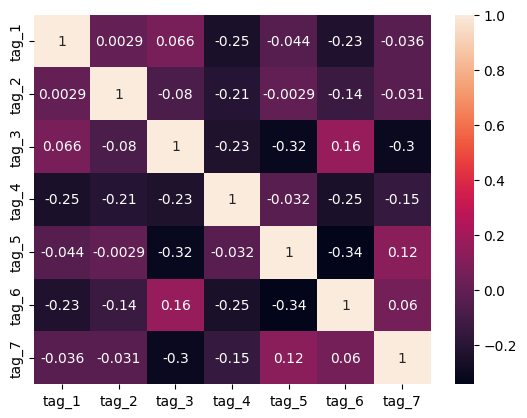

In [39]:
#creating a heatmap to visualise themes correlations
sns.heatmap(themes.corr(), annot = True)

In [40]:
#calculating a themes co-occurence count matrix
cooc_count = themes.T.dot(themes)
cooc_count

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,41,11,22,8,18,2,3
tag_2,11,28,12,5,13,2,2
tag_3,22,12,52,12,16,11,0
tag_4,8,5,12,36,16,1,1
tag_5,18,13,16,16,49,1,6
tag_6,2,2,11,1,1,16,2
tag_7,3,2,0,1,6,2,9


### Themes network graph & analysis

In [41]:
tags = ["tag_1", "tag_2", "tag_3", "tag_4", "tag_5", "tag_6", "tag_7"]
#creating a network graph

#creating an empty graph with no nodes
G = nx.Graph()

#adding themes as nodes
for tag in tags:
    G.add_node(tag)

#adding edges (connections between the themes) from cooccurence matrix
for i in tags:
    for j in tags:
        if i != j: #skipping self loops
            weight = cooc_count.loc[i, j] #looking up the cooccurence count between theme i and theme j
                                    # weight = the strength of the connection between themes
            if weight > 0: #creating an edge if the themes cooccur at least once 
                G.add_edge(i, j, weight = weight) #creating a connection and storing the frequency as the wedge weight


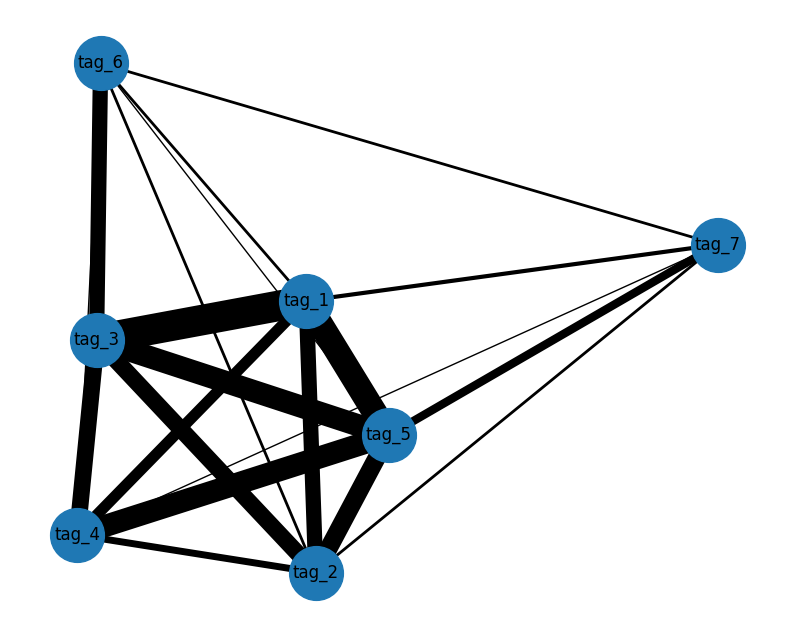

In [42]:
#drafting the network
plt.figure(figsize = (10, 8))

#calculating node positions to reveal clusters of themes calling spring_layout function
pos = nx.spring_layout(G, k = 1, seed = 42) #k =1 being optimal distance for the nodes and random seed set for reproducibiity

#drawing the network nodes using coordinates stored in pos
nx.draw_networkx_nodes(G, pos, node_size = 1500)
#assigning tags to each node on the graph
nx.draw_networkx_labels(G, pos)
#setting edge widths (setting strength of every connection)
edge_widths = [G[u][v]["weight"]
               for u, v, in G.edges()]
#drawing the edges - a line between connected themes
nx.draw_networkx_edges(G, pos, width = edge_widths)
#removing axes
plt.axis("off")
plt.show()

In [43]:
#finding most connected themes
centrality = nx.degree_centrality(G)
centrality

{'tag_1': 1.0,
 'tag_2': 1.0,
 'tag_3': 0.8333333333333333,
 'tag_4': 1.0,
 'tag_5': 1.0,
 'tag_6': 1.0,
 'tag_7': 0.8333333333333333}

The degree of cenrality measures numbers of connections a node has/(number of nodes in the nework - 1). \
A value of 1 suggests that themes 1, 2, 4, 5, and 6 are connected to all other nodes. \
0.83 inidcates tags 3 and 7 are connected to 5 out of six remaining nodes (5/(7-1)). \
That signifies that the network is extremely dense - most tags are connected to every other tag, with tags 3 and 7 missing only one connection.

In [44]:
#accounting for edge weights
weighted_degree = dict(nx.degree(G, weight = "weight"))
weighted_degree

{'tag_1': np.int64(64),
 'tag_2': np.int64(45),
 'tag_3': np.int64(73),
 'tag_4': np.int64(43),
 'tag_5': np.int64(70),
 'tag_6': np.int64(19),
 'tag_7': np.int64(14)}

When accounting for stregth of the connections theme 3 shows to be the most central theme by co-occurence - it is highly connected and strongly co-occuring. Similarly theme 5 also displays strong connections. \
Tag 1 indicates strong connection but less than theme 3. \
Themes 2 and 4 show moderate connectivity and co-occurence. \
Tag 6 shows to be a weakly connected theme, while tag 7 is indicated to have the least amount of connections.

In [45]:
#finding isolated themes
list(nx.isolates(G))

[]

There are no isolated nodes in the graph above.

In [46]:
communities_generator = nx.community.girvan_newman(G)
top_level_communities = next(communities_generator)
next_level_communities = next(communities_generator)
sorted(map(sorted, next_level_communities))

[['tag_1'], ['tag_2', 'tag_4', 'tag_5', 'tag_6', 'tag_7'], ['tag_3']]

The Grivan-Newman analysis showed that theme 1 and 3 are relatively isolated from the main cluster. \
While themes 2, 4, 5, 6, and 7 form a tightly connected cluster. 

Taking into account that it is a dense graph such community detection usually becomes unstable. Since almost every node is connected to every other node the algorithm is forced to split a network that has weak natural divisions resulting in a less meaningul outcome.

Themes 1, 2, 4, and 5 are connected to every other themes in the network. Tag 3 and 7 display a slightly weaker relationship due to not being connected to each other. There are no isolated themes. 

In [47]:
#checking the density of the network
nx.density(G)

0.9523809523809523

The co-occurence network exhibits a very high density. That extremely dense structure of the network suggests limited separation between thematic groups, despite Grivan-Newman algoritm identifying 3 communities. The results indicate a highly correlated thematic system rather than a presence of disticnt theme clusters. 

### Association Tests

#### Tags pairwise associations: 

*Jaccard index to measure set overlapp (absences ignored)*

In [48]:
#computing pairwise similarity (correlation) for each pair of tags
#defining jaccard measure function for binery association
jaccard = lambda a, b: binary_binary(a, b, measure = 'jaccard')

#computing the pairwise matrix
jaccard_matrix = corr(themes, jaccard)

#setting the diagonal manually to 1 
for tag in jaccard_matrix.index:
    jaccard_matrix.loc[tag, tag] = 1

jaccard_matrix.round(3) #rounding to improve interpretability

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,1.000,0.197,0.311,0.125,0.253,0.052,0.080
tag_2,0.197,1.000,0.183,0.097,0.209,0.067,0.079
tag_3,0.311,0.183,1.000,0.165,0.193,0.200,0.016
tag_4,0.125,0.097,0.165,1.000,0.236,0.037,0.043
tag_5,0.253,0.209,0.193,0.236,1.000,0.030,0.127
tag_6,0.052,0.067,0.200,0.037,0.030,1.000,0.115
tag_7,0.080,0.079,0.016,0.043,0.127,0.115,1.000


In [49]:
#verifying the calculation by checking one pair manually
a = themes["tag_1"]
b = themes["tag_2"]

intersection = ((a == 1 ) & (b == 1)).sum() #both tags present
union = ((a == 1) | (b == 1)).sum() #either tag present

#dividing intersection by union to obtain Jaccard similarity for one chosen pair
print(intersection / union)

0.1896551724137931


Strongest relationship: tag 1 & 3 = 31.1%; meaning 31.1% of all papers that have either tag 1 or 3 have both tags
Weakest relationship: tag 3 & 7 = 1.6%; only 1.6% combined occurances overlapp - tags barely appear together

#### *Phi coefficient to take absences into the account (Pearson correlation for binary variables)*

In [50]:
#creating list of tags using f-string
tag_list = themes[[f"tag_{i}" for i in range (1,8)]]

#computing the phi correlation matrix
phi_matrix = tag_list.corr(method = "pearson")
phi_matrix

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,1.000000,0.002943,0.066191,-0.249115,-0.044348,-0.230727,-0.035864
tag_2,0.002943,1.000000,-0.080407,-0.208712,-0.002878,-0.135831,-0.030773
tag_3,0.066191,-0.080407,1.000000,-0.233903,-0.315637,0.163045,-0.303284
tag_4,-0.249115,-0.208712,-0.233903,1.000000,-0.032174,-0.250432,-0.149490
tag_5,-0.044348,-0.002878,-0.315637,-0.032174,1.000000,-0.343497,0.122748
tag_6,-0.230727,-0.135831,0.163045,-0.250432,-0.343497,1.000000,0.059502
tag_7,-0.035864,-0.030773,-0.303284,-0.149490,0.122748,0.059502,1.000000


Interpretation Ranges: \
0.00 - 0.10 Negligible (no meaningful relationship) \
0.10 - 0.30 Small (weak tendency to appear together) \
0.30 - 0.50 Moderate (often co-occur) \
0.50 < Strong (almost always appear together) 

Negative tags indicate inverse relationship:
0.00 - -0.10 no meaningful relationship \
-0.10 - -0.30 weak avoidance \
-0.30 < strong mutual exclusivity 

Chi-square test for statistical significance

H0: Any two paired tags are independent \
H1: There is an association between the pair of tags

- p-value < 0.05
- significance: ($\alpha$) < 0.05
- degrees of freedom: (2-1)(2-1) = 1 | (n rows -1)(n columns -1)
- significant ($\chi^2$) > 3.841

In [51]:
#creating an empty list to store the results
results = []

#looping through every unique pair of tags & generating all possible pairs without repetitions
for tag1, tag2 in combinations(tag_list.columns, 2): 
    #creating a contingency table showing the frequency of each combination
    table = pd.crosstab(tag_list[tag1], tag_list[tag2])
    #performing the chi-square test on contingency table
    chi2, p, dof, expected = chi2_contingency(table) #dof = degrees of freedom; determines the chi-square distribution reference
                                                    #expected = expected frequencies under the assumption of independence -
                                                    #to compare against observed ones

#storing the results for this pair of tags
    results.append({
        "tag1": tag1,
        "tag2": tag2,
        "chi2": chi2,
        "p_value": p
    })

#converting the list of the results back into a dataframe
chi2_tags = pd.DataFrame(results)

#applying Bonferroni correction to significant pairs to account for multiple testing that was performed
chi2_tags["p_val_adjusted"] = chi2_tags["p_value"] / 21

#sorting the values based on higest chi square value
chi2_tags_sorted = chi2_tags.sort_values(by = "chi2", ascending = False).reset_index()
chi2_tags_sorted

,index,tag1,tag2,chi2,p_value,p_val_adjusted
0,18,tag_5,tag_6,10.547204,0.001164,0.000055
1,12,tag_3,tag_5,9.233661,0.002376,0.000113
2,14,tag_3,tag_7,7.612694,0.005796,0.000276
3,2,tag_1,tag_4,5.484734,0.019183,0.000913
4,16,tag_4,tag_6,5.198986,0.022600,0.001076
5,11,tag_3,tag_4,4.801298,0.028438,0.001354
6,4,tag_1,tag_6,4.351159,0.036984,0.001761
7,7,tag_2,tag_4,3.633584,0.056625,0.002696
8,13,tag_3,tag_6,1.957648,0.161765,0.007703
9,17,tag_4,tag_7,1.356290,0.244182,0.011628


Given the degrees of freedom (df = 1) and alpha value (($\alpha$) < 0.05) the chi square value is significant for the first 12 listed pairs of tags. The obeserved first 12 pairs of tags are far from what could be expected if the two tags were independent. These finding indicate that knowing one tag in a pair gives us information about the presence of the other. 

#### Theme vs Methodology

Residuals > 2 = observed more than expected \
Residuals < 2 = observed less than expected

In [52]:
#calculating the percentage of papers with each tag by methogology
methods_sum = (df2.groupby("method")[themes.columns].mean().mul(100).round(1))

methods_sum

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
method,,,,,,,
mixed,50.0,38.5,73.1,26.9,34.6,19.2,3.8
qual,31.8,18.2,34.1,40.9,65.9,9.1,15.9
quant,40.0,28.6,51.4,31.4,31.4,20.0,2.9


In [53]:
#creating an empty list to store the results
results_m = []

#looping over each tag in df2
for tag in themes.columns:
    #excluding papers with NaN values in method column
    subset = df2[["method", tag]].dropna()
    #creating a contingency table 
    table_m = pd.crosstab(subset["method"], subset[tag])
    #performing the chi-square test on contingency table
    chi2, p, dof, expected = chi2_contingency(table_m) #dof = degrees of freedom; determines the chi-square distribution reference
                                                    #expected = expected frequencies under the assumption of independence -
                                                    #to compare against observed ones

#storing the results for this pair of tags
    results_m.append({
        "theme": tag,
        "chi2": chi2,
        "p_value": p
    })

#converting the list of the results back into a dataframe
chi2_method = pd.DataFrame(results_m)

#sorting the values based on higest chi square value
chi2_method_sorted = chi2_method.sort_values(by = "chi2", ascending = False).reset_index()

chi2_method_sorted

,index,theme,chi2,p_value
0,4,tag_5,11.328337,0.003468
1,2,tag_3,10.012963,0.006694
2,6,tag_7,5.222083,0.073458
3,1,tag_2,3.534420,0.170809
4,0,tag_1,2.289963,0.318230
5,5,tag_6,2.222649,0.329123
6,3,tag_4,1.609088,0.447292


Given the degrees of freedom (df = 1) and alpha value (($\alpha$) < 0.05) and p-value < 0.05 the chi square value is significant for theme 3 and theme 5. That indicates a significant association between these tags and methodology.

In [54]:
#turning the tags column in the percentages methods_sum table into rows
pct_table = methods_sum.T.reset_index()
pct_table.columns = ["theme", "mixed", "qual", "quant"]

#merging the percentage methodology table with chi-square results
method_all = pct_table.merge(chi2_method[["theme", "p_value"]], on = "theme")

#highlighting significant results
method_all["significant"] = method_all["p_value"] < 0.05
method_all

,theme,mixed,qual,quant,p_value,significant
0,tag_1,50.0,31.8,40.0,0.318230,False
1,tag_2,38.5,18.2,28.6,0.170809,False
2,tag_3,73.1,34.1,51.4,0.006694,True
3,tag_4,26.9,40.9,31.4,0.447292,False
4,tag_5,34.6,65.9,31.4,0.003468,True
5,tag_6,19.2,9.1,20.0,0.329123,False
6,tag_7,3.8,15.9,2.9,0.073458,False


The distribution of tag 3 and 5 differ across methodologies more than would be expected by chance. It does not indicate that methodlogy causes the theme but it does show that both tag 3 and 5 are significantly associated with methodology (mixed methods and qual respectively). 

#### Theme vs Outcome

In [55]:
#calculating the percentage of papers with each tag by methogology
outcome_sum = (df2.groupby("results_category")[themes.columns].mean().mul(100).round(1))

outcome_sum

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
results_category,,,,,,,
both,50.0,40.4,46.2,30.8,51.9,3.8,9.6
challange,19.0,9.5,23.8,52.4,76.2,0.0,14.3
opportunity,34.4,15.6,71.9,28.1,18.8,43.8,3.1


In [56]:
#creating an empty list to store the results
results_o = []

#looping over each tag in df2
for tag in themes.columns:
    #creating a contingency table 
    table_o = pd.crosstab(df2["results_category"], df2[tag])
    #performing the chi-square test on contingency table
    chi2, p, dof, expected = chi2_contingency(table_o) #dof = degrees of freedom; determines the chi-square distribution reference
                                                    #expected = expected frequencies under the assumption of independence -
                                                    #to compare against observed ones

#storing the results for this pair of tags
    results_o.append({
        "theme": tag,
        "chi2": chi2,
        "p_value": p
    })

#converting the list of the results back into a dataframe
chi2_outcome = pd.DataFrame(results_o)
#rounding up p-values from exponential form for interpretability
chi2_outcome["p_value"] = chi2_outcome["p_value"].round(4)
#sorting the values based on higest chi square value
chi2_outcome_sorted = chi2_outcome.sort_values(by = "chi2", ascending = False).reset_index()
chi2_outcome_sorted

,index,theme,chi2,p_value
0,5,tag_6,29.140591,0.0000
1,4,tag_5,17.951948,0.0001
2,2,tag_3,12.186179,0.0023
3,1,tag_2,10.154806,0.0062
4,0,tag_1,6.443705,0.0399
5,3,tag_4,3.876391,0.1440
6,6,tag_7,2.158579,0.3398


Given the degrees of freedom (df = 1) and alpha value (($\alpha$) < 0.05) and p-value < 0.05 the chi square value is significant for all theme apart from 4 and 7. That indicates a significant association between these themes and outcome category.

In [57]:
#turning the tags column in the percentages outcome_sum table into rows
pct_table_o = outcome_sum.T.reset_index()
pct_table_o.columns = ["theme", "both", "challange", "opportunity"]

#merging the percentage methodology table with chi-square results
outcome_all = pct_table_o.merge(chi2_outcome[["theme", "p_value"]], on = "theme")

#highlighting significant results
outcome_all["significant"] = outcome_all["p_value"] < 0.05
outcome_all

,theme,both,challange,opportunity,p_value,significant
0,tag_1,50.0,19.0,34.4,0.0399,True
1,tag_2,40.4,9.5,15.6,0.0062,True
2,tag_3,46.2,23.8,71.9,0.0023,True
3,tag_4,30.8,52.4,28.1,0.1440,False
4,tag_5,51.9,76.2,18.8,0.0001,True
5,tag_6,3.8,0.0,43.8,0.0000,True
6,tag_7,9.6,14.3,3.1,0.3398,False


In the case of study outcome most of the themes identified show a significant association with the results of the study.

- Tags 3 and 6 are significantly associated with papers that only identified positive outcomes.
- Theme no 5 has been found to be significantly associated with papers only discussing the negative effects of AI in higher education.
- Tags 1 and 2 show to be associated with papers that identified both opportunities and challenges of AI use.
- Tag 1 having a higher probability (p-value of 0.039) indicating a 3.9% chance of observing results as extreme as these having occurred by chance which indicates only moderate evidence for this theme to be associated with the outcomes identified in papers results.

#### Theme vs Sample Size

In [58]:
#creating an empty list to store the results
results_s = []

#turing all sample size values into numeric values
df2["sample_size"] = pd.to_numeric(df2["sample_size"], errors = "coerce")

for tag in themes.columns:
    #creating a subset without NaN values in the sample size column
    subset_s = df2[["sample_size", tag]].dropna()

    #forcing pure numpy arrays
    #predictor
    X = subset_s["sample_size"].to_numpy(dtype = float)
    X = sm.add_constant(X) 

    #outcome
    y = subset_s[tag].to_numpy(dtype = int)
    
    model = sm.Logit(y, X).fit()

    results_s.append({
        "theme": tag,
        "coef": model.params[1],
        "p_value": model.pvalues[1],
        "odds_ratio": np.exp(model.params[1])
    })

logit_sample_size = pd.DataFrame(results_s)
logit_sample_size


Optimization terminated successfully.
         Current function value: 0.687602
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665667
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.682185
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.600029
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.663856
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.357486
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.221117
         Iterations 7


,theme,coef,p_value,odds_ratio
0,tag_1,-0.000099,0.575319,0.999901
1,tag_2,-0.000129,0.569570,0.999871
2,tag_3,0.000091,0.606509,1.000091
3,tag_4,0.000253,0.361107,1.000253
4,tag_5,-0.000185,0.548790,0.999815
5,tag_6,-0.000153,0.767467,0.999847
6,tag_7,-0.000068,0.878157,0.999932


coef: 
- positive - theme becomes more likely with larger sample sizes
- negative - theme becomes less likely
- values close to zero - no effect

All coeffieients are extremely close to 0 indicating that sample size has no meaninful effect on themes presence. 

P-value shows that none of the themes are significantly associated with sample size. 

Odds ratios:
- <1 - decreased likelihood
- 1 - no effect
- 1< - increased likelihood
\
All values are extremely close to 1, indicating that changing sample size by 1 unit has zero effect on theme probability. 

Logistic regression analyses showed no significant relationship between sample size and the presence of any themes identified (all p > 0.05). Odds ratios were approximately 1.00, indicating that changes in sample size did not meaningfully affect the likelihood of any theme occuring. 

#### Theme vs Region

In [59]:
#filling NaN values in region column as "unknown"
df2["region"] = df2["region"].fillna('Unknown')

#converting lists of continents into separate rows
df2_expanded = df2.explode("region").reset_index(drop = True)

#creating a list of themes
tags = ["tag_1", "tag_2", "tag_3", "tag_4", "tag_5", "tag_6", "tag_7"]

#creating a summary of each tags occurence per region
theme_by_region = (df2_expanded.groupby("region")[tags].sum())

#adding a column containing a total number of papers per region
theme_by_region["n_papers"] = (df2_expanded.groupby("region").size())

#adding percentage occurance of each tag for readability
for tag in tags:
    theme_by_region[f'{tag}_pct'] = (theme_by_region[tag] / theme_by_region["n_papers"] * 100).round(2)

theme_by_region

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,n_papers,tag_1_pct,tag_2_pct,tag_3_pct,tag_4_pct,tag_5_pct,tag_6_pct,tag_7_pct
region,,,,,,,,,,,,,,,
Unknown,12,2,14,14,19,3,4,33,36.36,6.06,42.42,42.42,57.58,9.09,12.12
africa,2,1,1,0,2,0,1,3,66.67,33.33,33.33,0.00,66.67,0.00,33.33
asia,8,10,15,6,7,7,1,25,32.00,40.00,60.00,24.00,28.00,28.00,4.00
europe,13,9,15,11,10,4,1,26,50.00,34.62,57.69,42.31,38.46,15.38,3.85
internat,2,2,1,2,4,0,0,5,40.00,40.00,20.00,40.00,80.00,0.00,0.00
north_am,2,2,4,2,2,1,1,7,28.57,28.57,57.14,28.57,28.57,14.29,14.29
oceania,0,0,1,1,1,0,0,1,0.00,0.00,100.00,100.00,100.00,0.00,0.00
south_am,3,2,3,1,4,2,1,7,42.86,28.57,42.86,14.29,57.14,28.57,14.29


### Multidimensional Scaling

In [60]:
#turning column labels into the index for MDS
themes_flipped = themes.transpose()

#calculating pairwise distances between themes
theme_distances = pairwise_distances(themes_flipped, metric = "euclidean")

#creating a dataframe for easier viewing
theme_distances_df = pd.DataFrame(theme_distances, index = themes.columns, columns = themes.columns) 
theme_distances_df

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,0.000000,6.855655,7.000000,7.810250,7.348469,7.280110,6.633250
tag_2,6.855655,0.000000,7.483315,7.348469,7.141428,6.324555,5.744563
tag_3,7.000000,7.483315,0.000000,8.000000,8.306624,6.782330,7.810250
tag_4,7.810250,7.348469,8.000000,0.000000,7.280110,7.071068,6.557439
tag_5,7.348469,7.141428,8.306624,7.280110,0.000000,7.937254,6.782330
tag_6,7.280110,6.324555,6.782330,7.071068,7.937254,0.000000,4.582576
tag_7,6.633250,5.744563,7.810250,6.557439,6.782330,4.582576,0.000000


Smaller distance indicates that a chosen pair of tags have a similar presence across papers. \
Theme 6 and 7 are the most similar in the dataset. \
Theme 3 and 5 are the most dissimilar pair. \

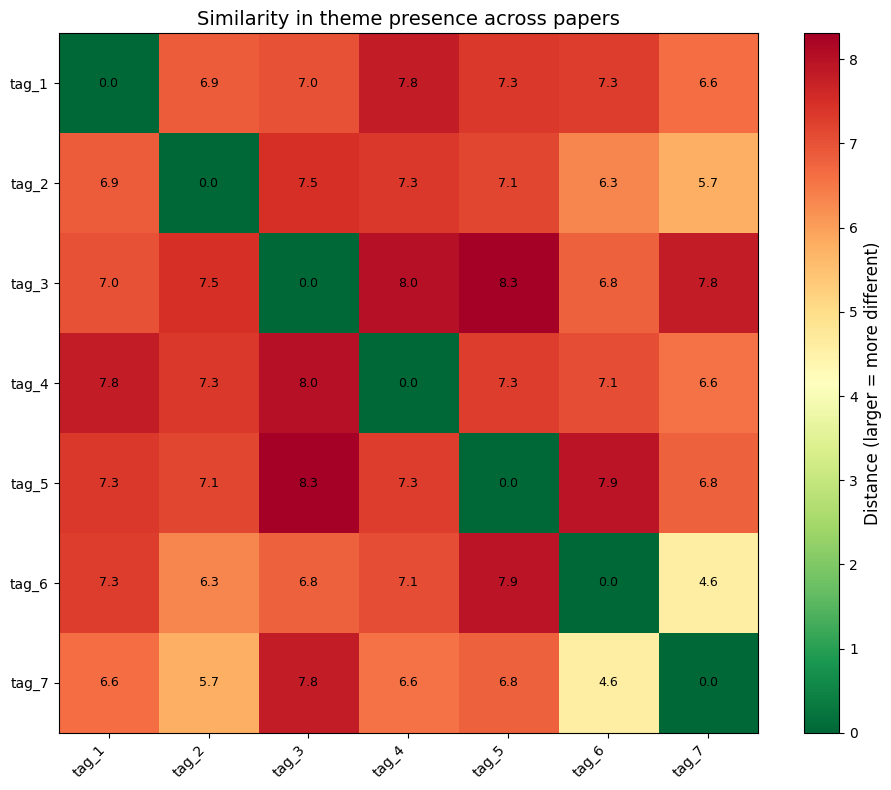

In [61]:
#visualising the distance matrix
fig, ax = plt.subplots(figsize = (10,8))

im = ax.imshow(theme_distances, cmap='RdYlGn_r')  # Red = more different, Green = more similar

#adding labels
ax.set_xticks(range(len(themes_flipped.index)))
ax.set_yticks(range(len(themes_flipped.index)))
ax.set_xticklabels(themes_flipped.index, rotation=45, ha='right')
ax.set_yticklabels(themes_flipped.index)

#adding colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Distance (larger = more different)', fontsize=12)

ax.set_title('Similarity in theme presence across papers', fontsize=14)

#adding distance values to cells
for i in range(len(theme_distances)):
    for j in range(len(theme_distances)):
        text = ax.text(j, i, f'{theme_distances[i, j]:.1f}',
                       ha='center', va='center', color='black', fontsize=9)
        
plt.tight_layout()
plt.show()

# DF3

In [62]:
#transforming the data to include a separate columns for each tag (accounting for primary tags = 2 and secondary tags = 1)
tags_2 = [
    {
        "paper_id": "P1",
        "results_category": "both",
        "method": "quant",
        "sample_size": 201,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P2",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P3",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 200,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P4",
        "results_category": "both",
        "method": "quant",
        "sample_size": 400,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P5",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 11,
        "tool": ["gpt", "other"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 2,
        "tag_7": 0, 
        },
    {
        "paper_id": "P6",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P7",
        "results_category": "both",
        "method": "quant",
        "sample_size": 938,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "north_am",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 2,
        },
    {
        "paper_id": "P8",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P9",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 2,
        },
    {
        "paper_id": "P10",
        "results_category": "challange",
        "method": "qual",
        "sample_size": 56,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": "interd",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 2,
        },
    {
        "paper_id": "P11",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 111,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P12",
        "results_category": "both",
        "method": "qual",
        "sample_size": 300,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": "interd",
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P13",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 503,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "interd",
        "region": "europe",
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P14",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1, 
        },
    {
        "paper_id": "P15",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 54,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0, 
        },
    {
        "paper_id": "P16",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 14878,
        "tool": "other",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P17",
        "results_category": "challange",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P18",
        "results_category": "both",
        "method": "qual",
        "sample_size": 36,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P19",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 695,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P20",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 40,
        "tool": "google",
        "focus_group": "student",
        "discipline": "stem",
        "region": "south_am",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P21",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P22",
        "results_category": "both",
        "method": "qual",
        "sample_size": 30,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P23",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P24",
        "results_category": "both",
        "method": "qual",
        "sample_size": 5,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P25",
        "results_category": "both",
        "method": "quant",
        "sample_size": 703,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "north_am",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 5,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P26",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 2,
        },
    {
        "paper_id": "P27",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 35,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P28",
        "results_category": "both",
        "method": "quant",
        "sample_size": 223,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P29",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 336,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P30",
        "results_category": "both",
        "method": "qual",
        "sample_size": 75,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P31",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 40,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P32",
        "results_category": "both",
        "method": "qual",
        "sample_size": 40,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P33",
        "results_category": "both",
        "method": "quant",
        "sample_size": 422,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P34",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P35",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 2,
        "tag_7": 1,
        },
    {
        "paper_id": "P36",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "internat",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1, 
        },
    {
        "paper_id": "P37",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 2,
        },
    {
        "paper_id": "P38",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P39",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 115,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0, 
        },
    {
        "paper_id": "P40",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 42,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P41",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P42",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 2,
        },
    {
        "paper_id": "P43",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P44",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 60,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P45",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 1484,
        "tool": ["gpt", "google", "microsoft", "claude"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P46",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 10,
        "tool": ["gpt", "google", "microsoft", "other"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "oceania",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P47",
        "results_category": "both",
        "method": "qual",
        "sample_size": 355,
        "tool": ["gpt", "google", "other"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 1,
        },
    {
        "paper_id": "P48",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 20,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P49",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P50",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 355,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P51",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P52",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 80,
        "tool": ["gpt", "microsoft"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 0, 
        },
    {
        "paper_id": "P53",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 193,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "interd",
        "region": "asia",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P54",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 385,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P55",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "other",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P56",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0, 
        },
    {
        "paper_id": "P57",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": "other",
        "focus_group": "student",
        "discipline": "hum",
        "region": "south_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P58",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 22,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 2,
        "tag_7": 0, 
        },
    {
        "paper_id": "P59",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 362,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P60",
        "results_category": "both",
        "method": "quant",
        "sample_size": 1195,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P61",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": np.nan,
        "tool": ["gpt", "google"],
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "north_am",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 1,
        "tag_5": 5,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P62",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 600,
        "tool": "other",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P63",
        "results_category": "both",
        "method": "quant",
        "sample_size": 361,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P64",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 1189,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 2,
        "tag_7": 1,
        },
    {
        "paper_id": "P65",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 25,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P66",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 24,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P67",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 918,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "hum",
        "region": "asia",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 0,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P68",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 14,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 2,
        },
    {
        "paper_id": "P69",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 76,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P70",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 365,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "south_am",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 2,
        },
    {
        "paper_id": "P71",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": "stem",
        "region": ["europe", "south_am"],
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P72",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 45,
        "tool": "other",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 0,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P73",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 12,
        "tool": ["gpt", "google", "microsoft"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P74",
        "results_category": "both",
        "method": "qual",
        "sample_size": 48,
        "tool": ["gpt", "google", "microsoft",  "claude"],
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P75",
        "results_category": "challange",
        "method": "mixed",
        "sample_size": 90,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P76",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 61,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 0,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P77",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P78",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P79",
        "results_category": "opportunity",
        "method": "qual",
        "sample_size": 4,
        "tool": "other",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 0, 
        },
    {
        "paper_id": "P80",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 1217,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": "interd",
        "region": "internat",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P81",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P82",
        "results_category": "both",
        "method": "qual",
        "sample_size": 20,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P83",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 0,
        "tag_4": 0,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P84",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": "asia",
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 0,
        },
    {
        "paper_id": "P85",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": "africa",
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 2,
        },
    {
        "paper_id": "P86",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 85,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P87",
        "results_category": "challange",
        "method": "quant",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 0,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P88",
        "results_category": "both",
        "method": "quant",
        "sample_size": 393,
        "tool": "gpt",
        "focus_group": np.nan,
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P89",
        "results_category": "challange",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 0,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P90",
        "results_category": "both",
        "method": "qual",
        "sample_size": 38,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P91",
        "results_category": "both",
        "method": "qual",
        "sample_size": 23,
        "tool": "gpt",
        "focus_group": "staff",
        "discipline": np.nan,
        "region": "africa",
        "tag_1": 1,
        "tag_2": 2,
        "tag_3": 1,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P92",
        "results_category": "opportunity",
        "method": "quant",
        "sample_size": 234,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": ["europe", "south_am"],
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P93",
        "results_category": "challange",
        "method": "quant",
        "sample_size": 122,
        "tool": ["gpt", "other"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P94",
        "results_category": "both",
        "method": "quant",
        "sample_size": 82,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "asia",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P95",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 140,
        "tool": ["gpt", "google", "claude"],
        "focus_group": "student",
        "discipline": "stem",
        "region": "africa",
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 0,
        "tag_7": 0,
        },
    {
        "paper_id": "P96",
        "results_category": "opportunity",
        "method": "mixed",
        "sample_size": 501,
        "tool": "gpt",
        "focus_group": "student",
        "discipline": "stem",
        "region": "north_am",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 0,
        },
    {
        "paper_id": "P97",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 1,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 0,
        "tag_5": 1,
        "tag_6": 2,
        "tag_7": 1,
        },
    {
        "paper_id": "P98",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 1054,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": np.nan,
        "region": "europe",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 2,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 1,
        },
    {
        "paper_id": "P99",
        "results_category": "both",
        "method": "mixed",
        "sample_size": 85,
        "tool": np.nan,
        "focus_group": "student",
        "discipline": "stem",
        "region": "europe",
        "tag_1": 2,
        "tag_2": 2,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P100",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P101",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 0,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 1,
        },
    {
        "paper_id": "P102",
        "results_category": "both",
        "method": "qual",
        "sample_size": np.nan,
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 1,
        },
    {
        "paper_id": "P103",
        "results_category": "both",
        "method": "qual",
        "sample_size": 138,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 1,
        "tag_6": 1,
        "tag_7": 1,
        },
    {
        "paper_id": "P104",
        "results_category": "both",
        "method": "qual",
        "sample_size": 116,
        "tool": np.nan,
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 1,
        "tag_4": 2,
        "tag_5": 2,
        "tag_6": 0,
        "tag_7": 1,
        },
    {
        "paper_id": "P105",
        "results_category": "both",
        "method": "qual",
        "sample_size": "37",
        "tool": "gpt",
        "focus_group": "mixed",
        "discipline": np.nan,
        "region": np.nan,
        "tag_1": 2,
        "tag_2": 1,
        "tag_3": 2,
        "tag_4": 1,
        "tag_5": 2,
        "tag_6": 1,
        "tag_7": 1,
        }
]

# DF3 analysis

In [63]:
#turning tags_2 dictionary into a dataframe
df3 = pd.DataFrame(tags_2).set_index("paper_id")
df3

,results_category,method,sample_size,tool,focus_group,discipline,region,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
paper_id,,,,,,,,,,,,,,
P1,both,quant,201,gpt,student,NaN,south_am,2,2,0,1,2,0,0
P2,opportunity,qual,NaN,NaN,mixed,NaN,NaN,0,0,1,2,0,1,0
P3,both,mixed,200,NaN,mixed,NaN,asia,1,2,2,1,1,1,0
P4,both,quant,400,gpt,student,NaN,asia,1,2,1,2,2,0,0
P5,opportunity,mixed,11,"[gpt, other]",mixed,NaN,europe,1,0,2,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P101,both,qual,NaN,NaN,mixed,NaN,NaN,2,0,2,1,1,1,1
P102,both,qual,NaN,gpt,mixed,NaN,NaN,2,1,2,1,2,1,1
P103,both,qual,138,NaN,mixed,NaN,NaN,2,1,2,1,1,1,1


In [64]:
df3.iloc[9]

results_category    challange
method                   qual
sample_size                56
tool                      gpt
focus_group               NaN
discipline             interd
region                 europe
tag_1                       0
tag_2                       0
tag_3                       0
tag_4                       0
tag_5                       2
tag_6                       0
tag_7                       2
Name: P10, dtype: object

In [65]:
df3.describe()

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,1.190476,0.866667,1.314286,0.980952,1.361905,0.561905,0.428571
std,0.748013,0.809400,0.763523,0.843310,0.889293,0.745806,0.648328
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,5.000000,2.000000,2.000000


In [66]:
#isolating themes columns into a separate daframe
themes2 = df3[["tag_1", "tag_2", "tag_3", "tag_4", "tag_5", "tag_6", "tag_7"]]
themes2

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
paper_id,,,,,,,
P1,2,2,0,1,2,0,0
P2,0,0,1,2,0,1,0
P3,1,2,2,1,1,1,0
P4,1,2,1,2,2,0,0
P5,1,0,2,0,0,2,0
...,...,...,...,...,...,...,...
P101,2,0,2,1,1,1,1
P102,2,1,2,1,2,1,1
P103,2,1,2,1,1,1,1


### Co-occurence analysis

In [67]:
#creating a correlation matrix
themes2.corr()

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,1.000000,0.344101,0.129877,-0.253324,-0.104625,-0.021340,0.048152
tag_2,0.344101,1.000000,0.037342,-0.144626,-0.052544,-0.145481,-0.109941
tag_3,0.129877,0.037342,1.000000,-0.110080,-0.296576,0.345433,-0.099897
tag_4,-0.253324,-0.144626,-0.110080,1.000000,0.201601,-0.395598,-0.108033
tag_5,-0.104625,-0.052544,-0.296576,0.201601,1.000000,-0.483529,0.111976
tag_6,-0.021340,-0.145481,0.345433,-0.395598,-0.483529,1.000000,0.053976
tag_7,0.048152,-0.109941,-0.099897,-0.108033,0.111976,0.053976,1.000000


<Axes: >

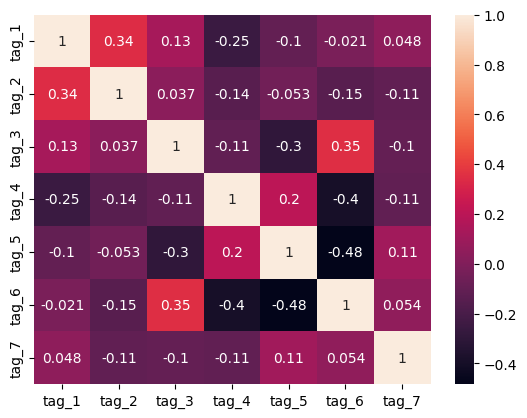

In [68]:
#creating a heatmap to visualise the correlations
sns.heatmap(themes2.corr(), annot = True)

In [69]:
#calculating co-occurence count matrix (weighted to account for primary and secondary tags)
cooc_count2 = themes2.T.dot(themes2)
cooc_count2

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,207,130,172,106,163,69,56
tag_2,130,147,122,79,120,42,33
tag_3,172,122,242,128,167,98,54
tag_4,106,79,128,175,156,32,38
tag_5,163,120,167,156,277,47,68
tag_6,69,42,98,32,47,91,28
tag_7,56,33,54,38,68,28,63


### Primary - Secondary Co-occurence matrix

In [70]:
#creating a cooccurence matrix to count how many times each secondary theme cooccurs with each primary theme
matrix = pd.DataFrame(0, index = tags, columns = tags)

#looping throug each paper
for _, row in df3.iterrows():
    #identifying primary and secondary tags for given paper 
    primary_tags = [t for t in tags if row[t] == 2]
    secondary_tags = [t for t in tags if row[t] == 1]
    #counting cooccurence 
    for p in primary_tags:
        for s in secondary_tags:
            matrix.loc[p, s] += 1

matrix

,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7
tag_1,0,22,14,15,16,18,16
tag_2,17,0,8,13,11,5,5
tag_3,23,25,0,19,25,20,15
tag_4,15,12,18,0,18,8,9
tag_5,20,14,22,19,0,8,16
tag_6,10,5,4,2,8,0,3
tag_7,3,2,8,2,2,4,0


rows = primary theme, columns = secondary theme: \

Strongest co-occurences:
- Theme 3 when identified as a primary theme shows the highest co-ocurence with most other themes as secondary ones, notably 2 and 5 (25 papers each), 1 (23 papers), and 6 (20 papers).
- Theme 5 as a primary tag co-occurs most often with secondary theme 3 (22) and 1 (20 papers)
- In the 22 papers where tag 1 was identified as a primary theme, tag 2 appeared as a secondary theme.
- Themes 6 and 7 when identified as primary show the lowest rate of secondary tag co-occurence

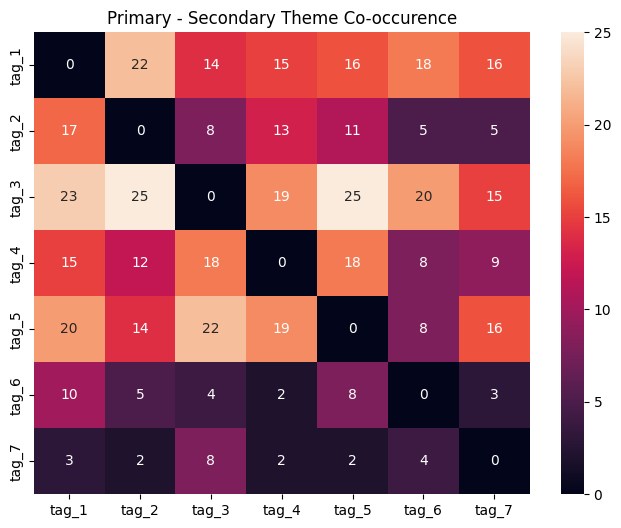

In [71]:
#plotting primary-secondary matrix as a heatmap
plt.figure(figsize = (8, 6))

sns.heatmap(matrix, annot = True)
plt.title("Primary - Secondary Theme Co-occurence")
plt.show()

#### Conditional percentages

In [72]:
#creating an empty list to store the results
results2 = []

for primary in tags: 
    #counting total number of papers where n theme is primary
    n_primary = (df3[primary] == 2).sum()

    for secondary in tags:
        #turning primary to secondary theme to compare it to itself for skiping the diagonal
        if primary == secondary: 
            continue #skip the diagonal 
        #count the papers where primary is primary and secondary is secondary
        count = ((df3[primary] == 2) & (df3[secondary] == 1)).sum()
        #calculate the percentage
        pct = count /n_primary * 100 if n_primary else 0
        #store the results
        results2.append([primary, secondary, count, pct])

#convert results into a dataframe
theme_perc = pd.DataFrame(results2, columns = ["primary_theme", "secondary_theme", "count", "percent"]).round(2)

#sorting the theme coocurennce based on prevalence
theme_p_sorted = theme_perc.sort_values(by = "percent", ascending = False).reset_index()
#show 10 most often coocuring themes
theme_p_sorted.head(10)

,index,primary_theme,secondary_theme,count,percent
0,38,tag_7,tag_3,8,88.89
1,30,tag_6,tag_1,10,62.50
2,6,tag_2,tag_1,17,60.71
3,0,tag_1,tag_2,22,53.66
4,21,tag_4,tag_5,18,50.00
5,20,tag_4,tag_3,18,50.00
6,34,tag_6,tag_5,8,50.00
7,13,tag_3,tag_2,25,48.08
8,15,tag_3,tag_5,25,48.08
9,26,tag_5,tag_3,22,46.81


Theme 7 (primary) and 3 (secondary) show the highest co-occurrence rate in the dataset (88.89% of papers with primary theme 7 mention theme 3 indirectly). The next significant pair includes tags 6 (primary) and 1 (secondary) (62.5%) and 2 (primary) and 1 (secondary) (60.71%). Next, representing 53.66% of papers where tag 1 is a primary theme, theme 2 is mentioned as secondary one. Theme 4 (primary) and secondary themes 5 and 3 are present in 50% of the papers analysed, same as primary tag 6 and secondary 5. Tag 3 when primary co-occurs with secondary tags 2 and 5 around 48% of the time. Lastly Primary theme 5 tends to mention theme 3 as secondary one 46.81% of the time. 